# Research: xlsx → PDF → `extract`

Companion to [research_xlsx_extract.ipynb](research_xlsx_extract.ipynb). That notebook proved
`method=extract` cannot ground against xlsx because Office files only get the
*Minimal* processing tier in Azure Content Understanding.

**Hypothesis here:** if we convert the workbook to PDF client-side, the PDF goes
through the *Standard (Layout)* pipeline and `extract` gets the OCR/layout spans
it needs — restoring grounding + per-field confidence + bounding boxes for xlsx
inputs.

## Constraints
- Target deployment: **Linux container VM** → no Excel COM, no `pywin32`.
- Engine candidates:
  1. **LibreOffice** (`soffice --headless --convert-to pdf`) — free, in-distro.
  2. **Aspose.Cells** (`aspose-cells-python`) — pure-Python wheel, paid (trial watermarks).

## The hard problem
Past attempts failed because default xlsx → PDF rendering wraps wide sheets across
many pages with mid-row column breaks — the PDF is unreadable, and so is the
`extract` output.

**Mitigation:** *xlsx page-setup preflight*. Before converting, mutate the
workbook in place with `openpyxl` to set:
- `fitToWidth = 1`, `fitToHeight = 0` (one page wide, as many tall as needed)
- `orientation = 'landscape'`
- `print_area = used range`
- `print_title_rows` if a header row exists

Both engines honor those properties. The preflight is the single most
important variable in this notebook — we measure with and without it.

## Test matrix
| # | Engine | Preflight | Notes |
|---|---|---|---|
| 1 | LibreOffice | none | reproduces "terrible" baseline |
| 2 | LibreOffice | fit-to-1-page-wide | the recommended config |
| 3 | Aspose.Cells | none | reference |
| 4 | Aspose.Cells | fit-to-1-page-wide | the recommended config |

For each PDF we record: page count, layout-markdown char count (vs. xlsx
baseline of 12,380), conversion time, and — the bottom line — how many
scalar + location-array cells `sovExtractV1` actually populates.

In [57]:
from __future__ import annotations
import json, os, time, uuid, shutil, subprocess, sys
from pathlib import Path
from dotenv import load_dotenv
import pandas as pd

from azure.ai.contentunderstanding import ContentUnderstandingClient
from azure.identity import DefaultAzureCredential

def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'demo' / 'sov').exists() or (p / '.git').exists():
            return p
    raise RuntimeError(f'Could not locate repo root from {start}')

REPO = _find_repo_root(Path.cwd().resolve())
print('REPO:', REPO)

for _cand in [REPO / '.env', REPO / 'apps' / 'workshop' / 'api' / '.env']:
    if _cand.exists():
        load_dotenv(_cand); print('env:', _cand); break

endpoint = os.environ.get('APP_CONTENT_UNDERSTANDING_ENDPOINT') or os.environ.get('CONTENTUNDERSTANDING_ENDPOINT')
if not endpoint:
    raise RuntimeError('Missing APP_CONTENT_UNDERSTANDING_ENDPOINT in .env')
print('endpoint:', endpoint)

DEMO = REPO / 'demo' / 'sov'
ATTACH = DEMO / 'attachments'
TPL_DIR = DEMO / 'reference' / 'analyzer-templates'
OUT = REPO / 'feedback' / 'underwriting' / 'research-output'
PDF_OUT = OUT / 'pdfs'
PDF_OUT.mkdir(parents=True, exist_ok=True)

TARGET_XLSX = ATTACH / '01_acme_SOV.xlsx'
assert TARGET_XLSX.exists(), f'TARGET_XLSX missing: {TARGET_XLSX}'

with open(TPL_DIR / 'sov_extraction.json', 'r', encoding='utf-8') as f:
    sov_extract_tpl = json.load(f)

client = ContentUnderstandingClient(endpoint=endpoint, credential=DefaultAzureCredential())
print('client OK')

REPO: C:\Users\jomedin\Documents\azure-ai-foundry-insurance
env: C:\Users\jomedin\Documents\azure-ai-foundry-insurance\.env
endpoint: https://ais-aidemos-dev-01.services.ai.azure.com/
client OK


## Engine availability
Detect which converters are installed. The notebook will skip variants whose
engine is missing rather than fail.

In [58]:
import importlib.util

def find_libreoffice() -> str | None:
    # Linux/macOS: `soffice` or `libreoffice` on PATH
    # Windows: shutil.which finds it if installed via standard installer
    for name in ('soffice', 'libreoffice'):
        p = shutil.which(name)
        if p: return p
    # Common Windows fallback paths
    for p in (r'C:\Program Files\LibreOffice\program\soffice.exe',
              r'C:\Program Files (x86)\LibreOffice\program\soffice.exe'):
        if Path(p).exists(): return p
    return None

def _has_module(name: str) -> bool:
    try:
        return importlib.util.find_spec(name) is not None
    except (ModuleNotFoundError, ImportError, ValueError):
        return False

LIBREOFFICE = find_libreoffice()
ASPOSE_AVAILABLE = _has_module('aspose.cells')
OPENPYXL_AVAILABLE = _has_module('openpyxl')
PYPDFIUM_AVAILABLE = _has_module('pypdfium2')

print(f'LibreOffice : {LIBREOFFICE or "NOT FOUND  (apt-get install libreoffice-calc, or `winget install TheDocumentFoundation.LibreOffice`)"}')
print(f'Aspose.Cells: {"available" if ASPOSE_AVAILABLE else "NOT INSTALLED  (pip install aspose-cells-python)"}')
print(f'openpyxl    : {"available" if OPENPYXL_AVAILABLE else "NOT INSTALLED  (pip install openpyxl)  -- required for preflight"}')
print(f'pypdfium2   : {"available" if PYPDFIUM_AVAILABLE else "NOT INSTALLED  (pip install pypdfium2)  -- required for visual triage"}')


LibreOffice : C:\Program Files\LibreOffice\program\soffice.exe
Aspose.Cells: NOT INSTALLED  (pip install aspose-cells-python)
openpyxl    : available
pypdfium2   : available


## Page-setup preflight
Force fit-to-1-page-wide, landscape, full used range. Returns a new path so
the original input is untouched.

In [73]:
import math

_EMU_PER_PX = 9525
_DEFAULT_ROW_PX = 20
_DEFAULT_COL_PX = 64

def _image_extent_cells(image) -> tuple[int | None, int | None]:
    """Approximate (end_row_1based, end_col_1based) for an anchored image."""
    anc = image.anchor
    try:
        from_col = anc._from.col + 1
        from_row = anc._from.row + 1
    except Exception:
        return (None, None)
    cx = cy = None
    ext = getattr(anc, 'ext', None)
    if ext is not None and getattr(ext, 'cx', None) and getattr(ext, 'cy', None):
        cx, cy = ext.cx, ext.cy
    to = getattr(anc, 'to', None)
    if to is not None:
        try:
            return (to.row + 1, to.col + 1)
        except Exception:
            pass
    if cx and cy:
        cols = max(1, math.ceil(cx / _EMU_PER_PX / _DEFAULT_COL_PX))
        rows = max(1, math.ceil(cy / _EMU_PER_PX / _DEFAULT_ROW_PX))
        return (from_row + rows, from_col + cols)
    return (from_row + 10, from_col + 5)


def _measure_cell_text(value) -> int:
    if value is None:
        return 0
    s = str(value)
    return max((len(line) for line in s.splitlines()), default=0)


def autofit_columns(ws, *, min_width: float = 6.0, max_width: float = 60.0,
                    padding: float = 1.2) -> None:
    """Approximate Excel's 'AutoFit Column Width', honoring merged ranges."""
    from openpyxl.utils import get_column_letter

    merged_lookup: dict[tuple[int, int], tuple[int, int]] = {}
    for mr in ws.merged_cells.ranges:
        for r in range(mr.min_row, mr.max_row + 1):
            for c in range(mr.min_col, mr.max_col + 1):
                merged_lookup[(r, c)] = (mr.min_col, mr.max_col)

    col_max: dict[int, float] = {}
    last_row = ws.max_row or 1
    for row_cells in ws.iter_rows(min_row=1, max_row=last_row, values_only=False):
        for cell in row_cells:
            v = cell.value
            if v in (None, ''):
                continue
            text_w = _measure_cell_text(v)
            if not text_w:
                continue
            r, c = cell.row, cell.column
            if (r, c) in merged_lookup:
                cmin, cmax = merged_lookup[(r, c)]
                span = cmax - cmin + 1
                share = max(1.0, text_w / span)
                for cc in range(cmin, cmax + 1):
                    col_max[cc] = max(col_max.get(cc, 0), share)
            else:
                col_max[c] = max(col_max.get(c, 0), text_w)

    for col_idx, width in col_max.items():
        new_w = max(min_width, min(max_width, width * padding + 1))
        ws.column_dimensions[get_column_letter(col_idx)].width = new_w


def reset_row_heights(ws) -> None:
    """Drop explicit row heights so the renderer uses defaults."""
    for rd in ws.row_dimensions.values():
        rd.height = None


def apply_print_preflight(xlsx_path: Path, out_path: Path | None = None,
                          autofit: bool = True,
                          print_gridlines: bool = False) -> Path:
    """Mutate workbook page-setup so the PDF engine produces a 1-page-wide layout
    that includes anchored images and has columns wide enough to show every value.

    `print_gridlines=False` (default) reproduces Excel's natural print output:
    only the borders the workbook itself defines are visible. Set to True if you
    want Excel's standard light gridlines printed everywhere.
    """
    from openpyxl import load_workbook
    from openpyxl.worksheet.page import PageMargins
    from openpyxl.utils import get_column_letter

    out_path = out_path or xlsx_path.with_name(xlsx_path.stem + '.print-ready.xlsx')
    wb = load_workbook(xlsx_path)
    for ws in wb.worksheets:
        ws.page_setup.fitToWidth = 1
        ws.page_setup.fitToHeight = 0
        ws.sheet_properties.pageSetUpPr.fitToPage = True
        ws.page_setup.orientation = ws.ORIENTATION_LANDSCAPE
        ws.page_setup.paperSize = ws.PAPERSIZE_LETTER

        ws.print_options.gridLines = print_gridlines
        ws.print_options.gridLinesSet = print_gridlines

        if autofit:
            autofit_columns(ws)
            reset_row_heights(ws)

        last_row = ws.max_row or 1
        last_col = ws.max_column or 1
        for im in list(ws._images):
            er, ec = _image_extent_cells(im)
            if er: last_row = max(last_row, er)
            if ec: last_col = max(last_col, ec)
        ws.print_area = f'A1:{get_column_letter(last_col)}{last_row}'

        ws.page_margins = PageMargins(left=0.3, right=0.3, top=0.3, bottom=0.3, header=0.2, footer=0.2)
        ws.print_title_rows = '1:1'

        widest = max((cd.width for cd in ws.column_dimensions.values() if cd.width), default=0)
        print(f'  preflighted sheet={ws.title!r}  print_area={ws.print_area}  images={len(ws._images)}  widest_col={widest:.1f}  gridlines={print_gridlines}')
    wb.save(out_path)
    return out_path


PREFLIGHTED_XLSX = apply_print_preflight(TARGET_XLSX, PDF_OUT / (TARGET_XLSX.stem + '.print-ready.xlsx'))
print(f'preflighted: {PREFLIGHTED_XLSX}  ({PREFLIGHTED_XLSX.stat().st_size:,} bytes)')


  preflighted sheet='SOV'  print_area='SOV'!$A$1:$O$54  images=1  widest_col=60.0  gridlines=False
preflighted: C:\Users\jomedin\Documents\azure-ai-foundry-insurance\feedback\underwriting\research-output\pdfs\01_acme_SOV.print-ready.xlsx  (24,322 bytes)


## Converter implementations

In [60]:
def convert_libreoffice(xlsx_path: Path, out_dir: Path) -> Path:
    if not LIBREOFFICE:
        raise RuntimeError('LibreOffice not found on PATH')
    out_dir.mkdir(parents=True, exist_ok=True)
    cmd = [LIBREOFFICE, '--headless', '--nologo', '--nofirststartwizard',
           '--convert-to', 'pdf:calc_pdf_Export',
           '--outdir', str(out_dir), str(xlsx_path)]
    proc = subprocess.run(cmd, capture_output=True, text=True, timeout=180)
    pdf = out_dir / (xlsx_path.stem + '.pdf')
    if not pdf.exists():
        raise RuntimeError(f'LibreOffice did not produce PDF.\nSTDOUT: {proc.stdout}\nSTDERR: {proc.stderr}')
    return pdf


def rasterize_pdf_to_tiff(pdf_path: Path, out_dir: Path, dpi: int = 600) -> Path:
    """Render every PDF page to a single multi-page TIFF (LZW-compressed).
    CU accepts image/tiff directly via begin_analyze_binary; multi-page TIFF
    becomes one analyze call with N `contents` entries.

    Why we need this: when CU receives a vector PDF it reads the embedded
    text stream, which can mis-merge tightly-packed table rows. Rasterizing
    to TIFF forces the OCR/layout path, which uses pure spatial geometry
    and produces deterministic row identity.
    """
    import pypdfium2 as pdfium
    from PIL import Image

    out_dir.mkdir(parents=True, exist_ok=True)
    src = pdfium.PdfDocument(str(pdf_path))
    scale = dpi / 72.0
    imgs = [page.render(scale=scale).to_pil().convert('RGB') for page in src]
    if not imgs:
        raise RuntimeError(f'no pages in {pdf_path}')
    tiff = out_dir / (pdf_path.stem + '.tiff')
    imgs[0].save(tiff, 'TIFF', save_all=True, append_images=imgs[1:],
                 compression='tiff_lzw', dpi=(dpi, dpi))
    return tiff


## PDF quality scorecard
Before judging extraction, measure the conversion itself. We compare PDF
layout-markdown (12,380 chars on the original xlsx) and count pages.
If a PDF loses content, no extraction tweak will save it.

In [61]:
BASELINE_LAYOUT_CHARS = 12380  # from research_xlsx_extract.ipynb variant 01_layout_only

def _result_to_dict(r):
    if hasattr(r, 'as_dict'): return r.as_dict()
    return json.loads(json.dumps(r, default=lambda o: getattr(o, '__dict__', str(o))))

def measure_pdf_layout(pdf_path: Path) -> dict:
    """Run prebuilt-layout on the PDF and return content-quality stats."""
    t0 = time.perf_counter()
    with open(pdf_path, 'rb') as f:
        poller = client.begin_analyze_binary(
            analyzer_id='prebuilt-layout',
            binary_input=f.read(),
            content_type='application/pdf',
        )
    payload = _result_to_dict(poller.result())
    elapsed = round(time.perf_counter() - t0, 2)
    contents = payload.get('contents', [])
    md_total = sum(len(c.get('markdown') or '') for c in contents)
    pages = max((c.get('endPageNumber') or 0) for c in contents) if contents else 0
    # Save raw layout output for diffing
    (pdf_path.parent / (pdf_path.stem + '.layout.json')).write_text(
        json.dumps(payload, indent=2), encoding='utf-8')
    return {
        'pdf_pages': pages,
        'pdf_size_bytes': pdf_path.stat().st_size,
        'layout_md_chars': md_total,
        'pct_of_xlsx_baseline': round(md_total * 100 / BASELINE_LAYOUT_CHARS, 1),
        'layout_elapsed_sec': elapsed,
    }

## Run `sovExtractV1` on each PDF

In [62]:
def _safe_aid(name: str) -> str:
    cleaned = ''.join(ch if (ch.isalnum() or ch == '_') else '_' for ch in name)
    return f'research_{cleaned}_{uuid.uuid4().hex[:6]}'

def ensure_analyzer(aid: str, body: dict):
    try: client.delete_analyzer(analyzer_id=aid)
    except Exception: pass
    client.begin_create_analyzer(analyzer_id=aid, resource=body).result()


_CT_BY_SUFFIX = {
    '.pdf':  'application/pdf',
    '.tif':  'image/tiff',
    '.tiff': 'image/tiff',
    '.png':  'image/png',
    '.jpg':  'image/jpeg',
    '.jpeg': 'image/jpeg',
}


def run_sov_extract_on_pdf(pdf_path: Path, label: str, content_type: str | None = None) -> dict:
    """Send the file to CU and run sovExtractV1. Despite the name we accept
    any binary CU understands (PDF / TIFF / image)."""
    aid = _safe_aid(label)
    raw_path = PDF_OUT / f'{label}.extract.json'
    ct = content_type or _CT_BY_SUFFIX.get(pdf_path.suffix.lower(), 'application/pdf')
    t0 = time.perf_counter()
    try:
        ensure_analyzer(aid, sov_extract_tpl)
        with open(pdf_path, 'rb') as f:
            poller = client.begin_analyze_binary(analyzer_id=aid, binary_input=f.read(), content_type=ct)
        payload = _result_to_dict(poller.result())
        raw_path.write_text(json.dumps(payload, indent=2), encoding='utf-8')
    finally:
        try: client.delete_analyzer(analyzer_id=aid)
        except Exception: pass
    elapsed = round(time.perf_counter() - t0, 2)

    fields = (payload.get('contents') or [{}])[0].get('fields', {})
    scalars_total = scalars_pop = 0
    for v in fields.values():
        if isinstance(v, dict) and v.get('type') in ('string', 'number', 'date', 'integer'):
            scalars_total += 1
            if any(kk.startswith('value') and v.get(kk) not in (None, '', [], {}) for kk in v):
                scalars_pop += 1
    locs = (fields.get('Locations') or {}).get('valueArray', [])
    sub_total = sub_pop = 0
    confs = []
    for it in locs:
        for fv in (it.get('valueObject') or {}).values():
            sub_total += 1
            if any(kk.startswith('value') and fv.get(kk) not in (None, '', [], {}) for kk in fv):
                sub_pop += 1
                if isinstance(fv.get('confidence'), (int, float)):
                    confs.append(fv['confidence'])
    return {
        'extract_elapsed_sec': elapsed,
        'content_type': ct,
        'payload_bytes': pdf_path.stat().st_size,
        'scalars': f'{scalars_pop}/{scalars_total}',
        'locations_rows': len(locs),
        'location_cells': f'{sub_pop}/{sub_total}',
        'cell_pct': round(sub_pop * 100 / sub_total, 1) if sub_total else 0.0,
        'mean_conf': round(sum(confs) / len(confs), 3) if confs else None,
        'min_conf': round(min(confs), 3) if confs else None,
        'extract_path': str(raw_path.relative_to(REPO)),
    }


## Run the matrix

In [82]:
def run_one(label: str, source_xlsx: Path, *, rasterize_tiff: bool = False, dpi: int = 600) -> dict:
    """Convert source xlsx with LibreOffice, optionally rasterize the PDF to a
    multi-page TIFF, then run sovExtractV1."""
    flavor = f'tiff@{dpi}' if rasterize_tiff else 'pdf'
    print(f'\n=== {label}  source={source_xlsx.name}  flavor={flavor} ===')
    row: dict = {'variant': label, 'source': source_xlsx.name, 'flavor': flavor}
    t0 = time.perf_counter()
    try:
        doc = convert_libreoffice(source_xlsx, PDF_OUT / label)
        if rasterize_tiff:
            doc = rasterize_pdf_to_tiff(doc, PDF_OUT / label, dpi=dpi)
        row['convert_sec'] = round(time.perf_counter() - t0, 2)
        row['pdf_path'] = str(doc.relative_to(REPO))
        print(f'  doc: {doc.relative_to(REPO)}  ({doc.stat().st_size:,} bytes)  in {row["convert_sec"]}s')
    except Exception as e:
        row['convert_sec'] = round(time.perf_counter() - t0, 2)
        row['error'] = str(e)[:300]
        print(f'  ! convert failed: {e}')
        return row
    try:
        if doc.suffix.lower() == '.pdf':
            row.update(measure_pdf_layout(doc))
            print(f'  layout: {row["layout_md_chars"]:,} chars  ({row["pct_of_xlsx_baseline"]}% of xlsx baseline)  pages={row["pdf_pages"]}')
    except Exception as e:
        row['error'] = (row.get('error') or '') + f' | layout: {e}'[:300]
        print(f'  ! layout failed: {e}')
    try:
        row.update(run_sov_extract_on_pdf(doc, label))
        print(f'  extract: scalars={row["scalars"]}  cells={row["location_cells"]} ({row["cell_pct"]}%)  mean_conf={row["mean_conf"]}')
    except Exception as e:
        row['error'] = (row.get('error') or '') + f' | extract: {e}'[:300]
        print(f'  ! extract failed: {e}')
    return row


results: list[dict] = []

if not LIBREOFFICE:
    raise RuntimeError('LibreOffice not installed -- this notebook requires it.')

# Variant A: text/vector PDF (LibreOffice + preflight). CU reads embedded text.
results.append(run_one('02_libreoffice_preflight', PREFLIGHTED_XLSX))

# Variant B: same PDF rasterized to multi-page TIFF at 600 DPI. CU OCRs the
# pages, which gives deterministic row identity at the cost of a bigger payload.
if PYPDFIUM_AVAILABLE:
    results.append(run_one('04_libreoffice_tiff_600', PREFLIGHTED_XLSX, rasterize_tiff=True, dpi=600))
    # Variant C: 800 DPI -- check if higher resolution recovers the remaining edge cases.
    results.append(run_one('05_libreoffice_tiff_800', PREFLIGHTED_XLSX, rasterize_tiff=True, dpi=800))
else:
    print('\n(skipping TIFF variants -- pypdfium2 not installed)')

print(f'\n{len(results)} variants ran.')



=== 02_libreoffice_preflight  source=01_acme_SOV.print-ready.xlsx  flavor=pdf ===
  doc: feedback\underwriting\research-output\pdfs\02_libreoffice_preflight\01_acme_SOV.print-ready.pdf  (134,200 bytes)  in 7.89s
  layout: 7,244 chars  (58.5% of xlsx baseline)  pages=1
  extract: scalars=17/17  cells=264/484 (54.5%)  mean_conf=0.768

=== 04_libreoffice_tiff_600  source=01_acme_SOV.print-ready.xlsx  flavor=tiff@600 ===
  doc: feedback\underwriting\research-output\pdfs\04_libreoffice_tiff_600\01_acme_SOV.print-ready.tiff  (2,325,046 bytes)  in 3.37s
  extract: scalars=17/17  cells=266/484 (55.0%)  mean_conf=0.777

=== 05_libreoffice_tiff_800  source=01_acme_SOV.print-ready.xlsx  flavor=tiff@800 ===
  doc: feedback\underwriting\research-output\pdfs\05_libreoffice_tiff_800\01_acme_SOV.print-ready.tiff  (3,142,334 bytes)  in 3.54s
  extract: scalars=17/17  cells=269/484 (55.6%)  mean_conf=0.771

3 variants ran.


In [64]:
if results:
    df = pd.DataFrame(results)
    cols = ['variant', 'engine', 'convert_sec', 'pdf_pages', 'layout_md_chars',
            'pct_of_xlsx_baseline', 'scalars', 'locations_rows', 'location_cells',
            'cell_pct', 'mean_conf', 'min_conf', 'error']
    df_view = df[[c for c in cols if c in df.columns]]
    display(df_view)
else:
    print('No engines available. Install LibreOffice or aspose-cells-python and re-run.')

,variant,convert_sec,pdf_pages,layout_md_chars,pct_of_xlsx_baseline,scalars,locations_rows,location_cells,cell_pct,mean_conf,min_conf
0,02_libreoffice_preflight,2.37,1.0,9331.0,75.4,17/17,23,254/506,50.2,0.607,0.452
1,04_libreoffice_tiff_600,2.95,NaN,NaN,NaN,17/17,22,269/484,55.6,0.601,0.447


## Visual triage
If a variant looks bad in the table, render its first PDF page as PNG so we
can see *why* (column overflow, mid-row break, fonts replaced, etc.).
Requires `pypdfium2` (pure Python, Linux-friendly): `pip install pypdfium2`.


--- 02_libreoffice_preflight  page 1 (feedback\underwriting\research-output\pdfs\02_libreoffice_preflight\01_acme_SOV.print-ready.page1.png)


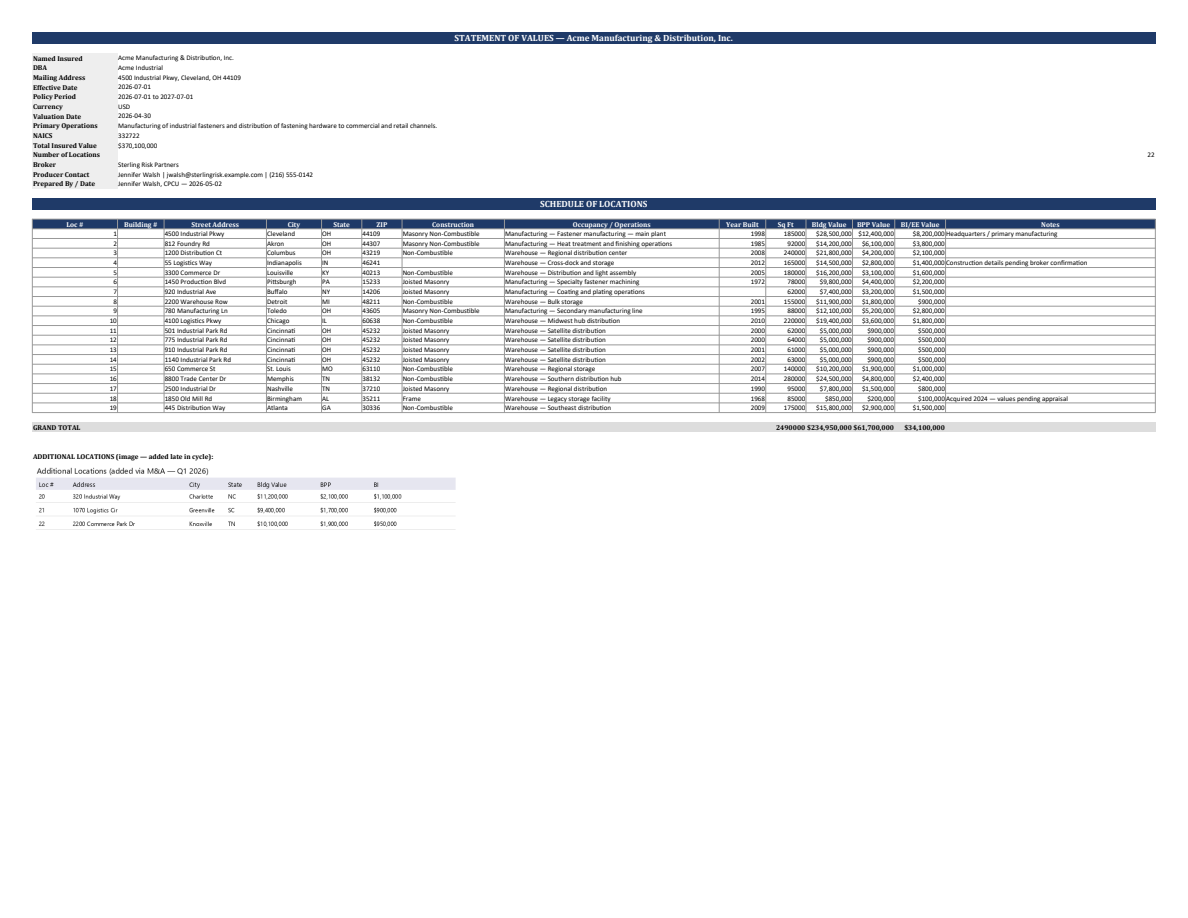


--- 04_libreoffice_tiff_600  page 1 (feedback\underwriting\research-output\pdfs\04_libreoffice_tiff_600\01_acme_SOV.print-ready.page1.png)


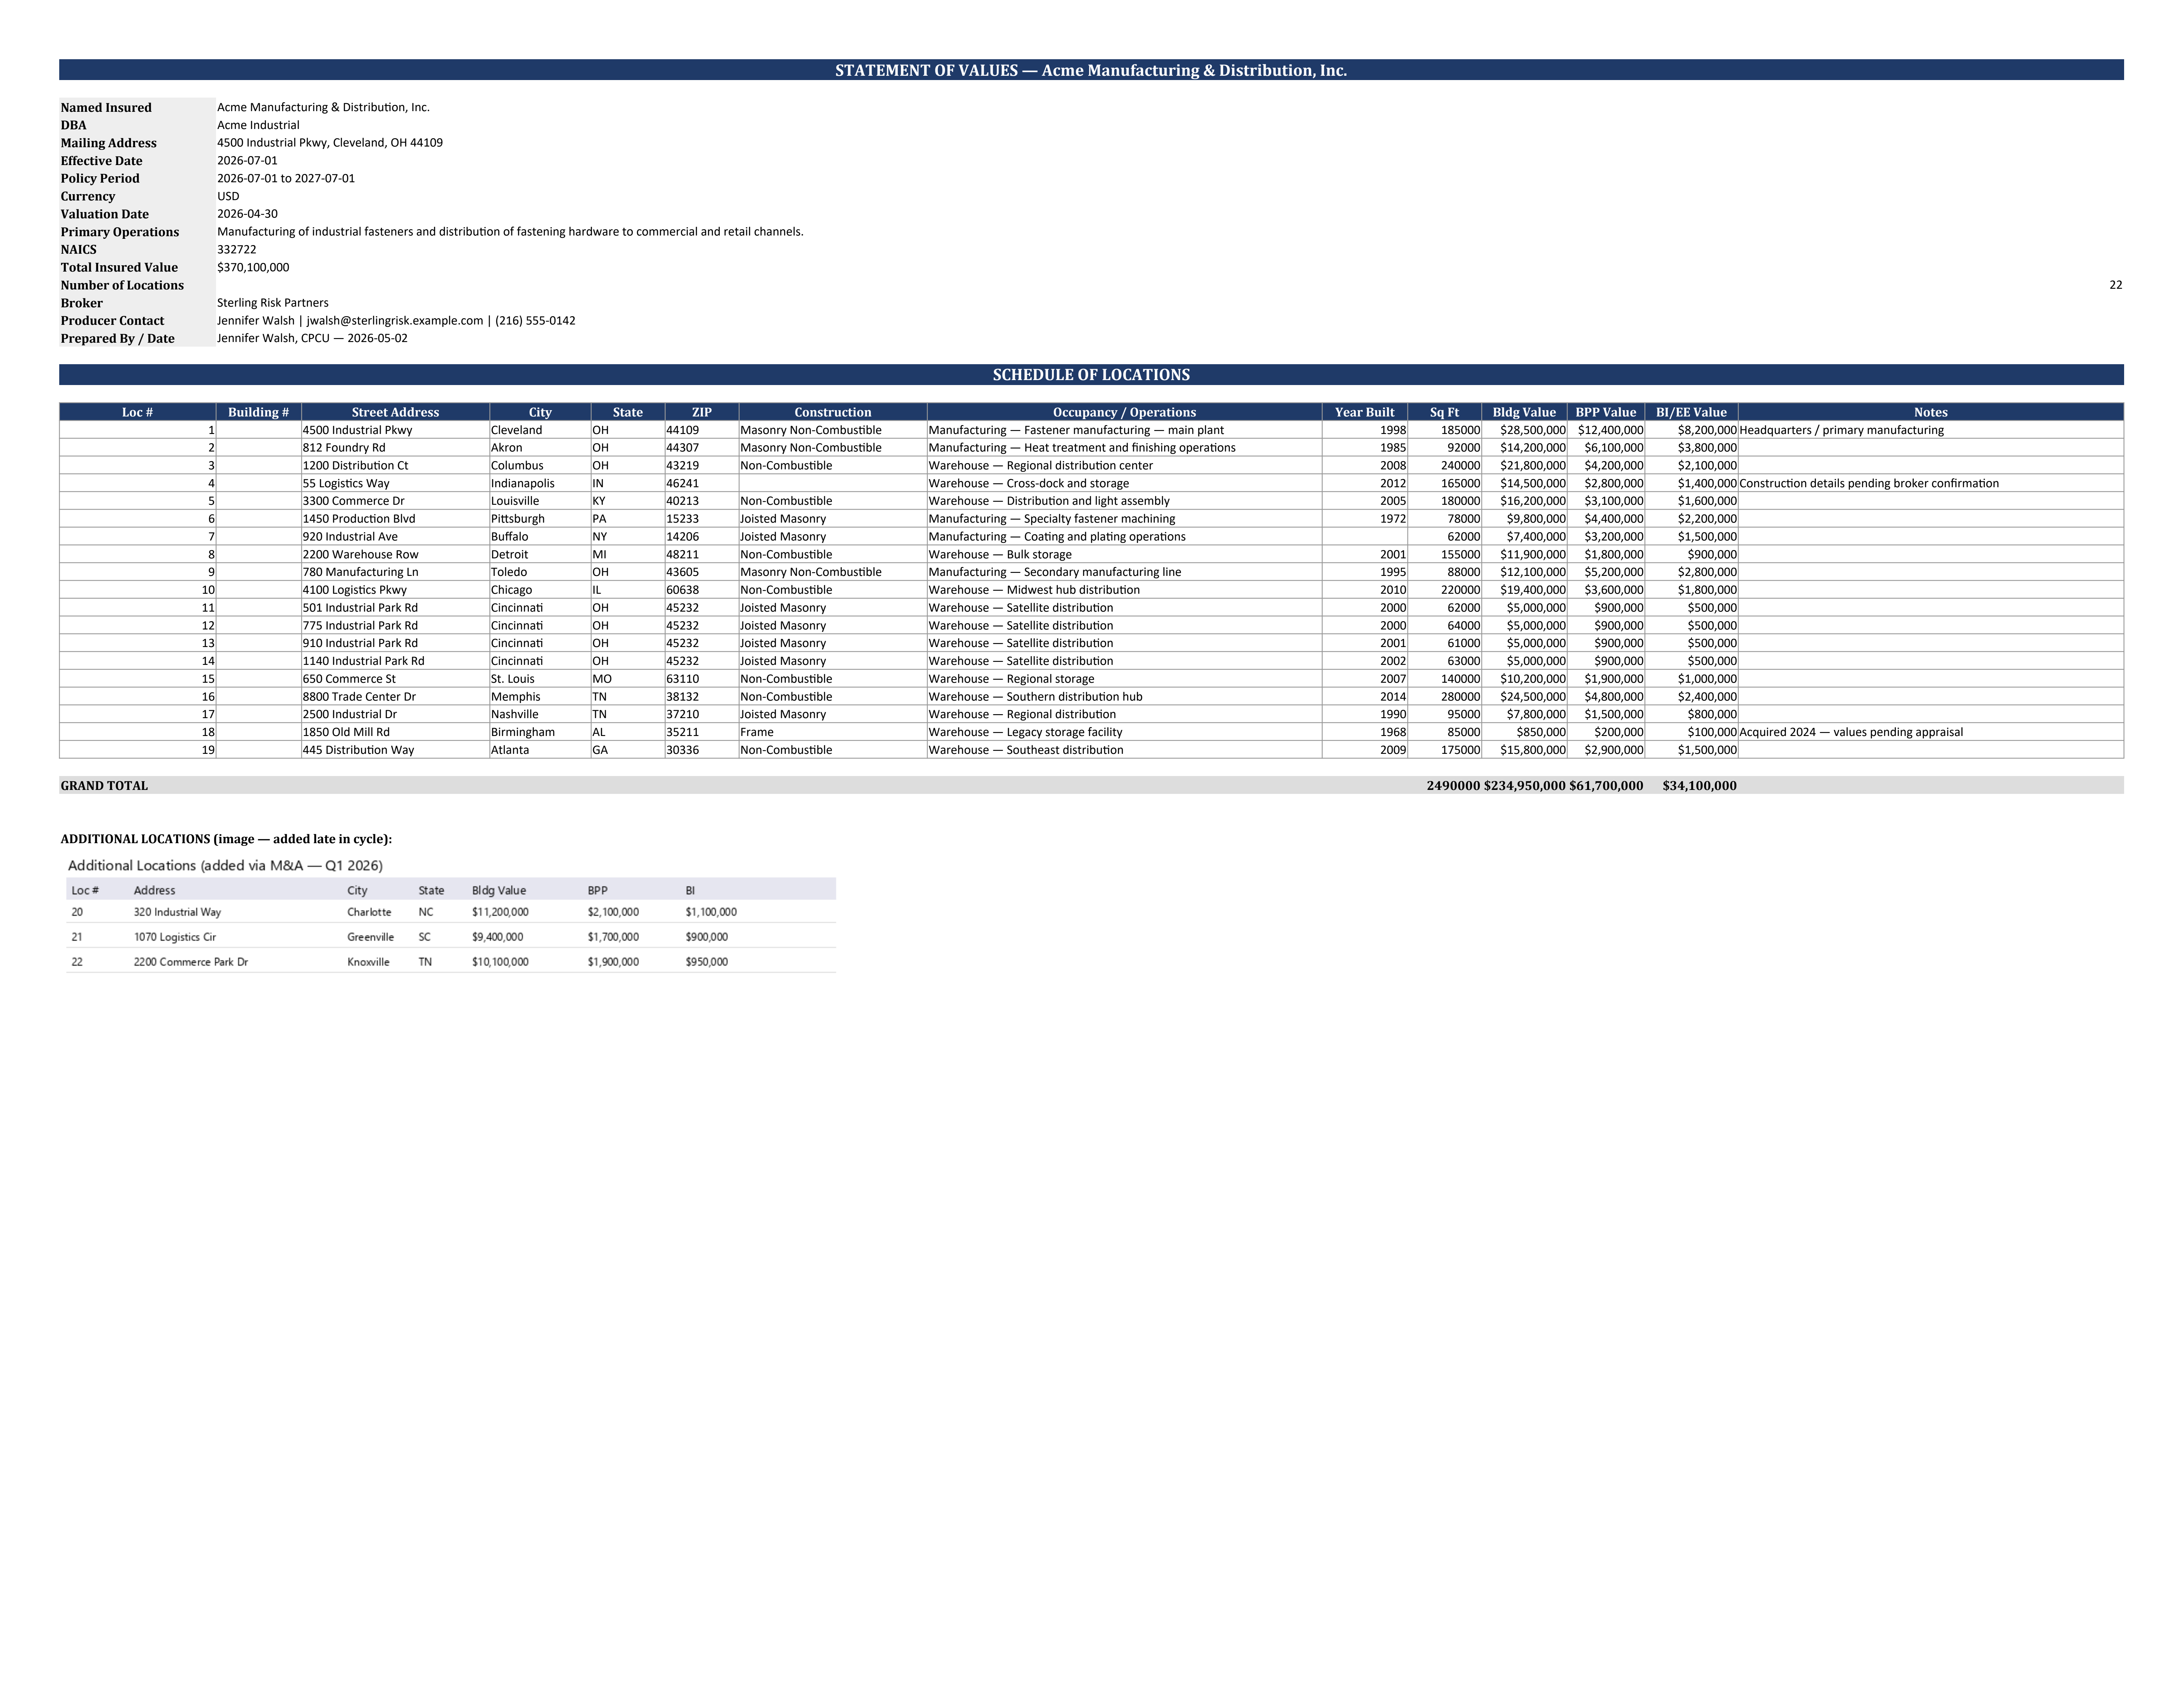

In [78]:
def render_first_page(doc_path: Path, png_path: Path | None = None, scale: float = 1.5) -> Path | None:
    """Render page 1 of a PDF or TIFF to PNG so we can eyeball what CU saw."""
    suffix = doc_path.suffix.lower()
    png_path = png_path or doc_path.with_suffix('.page1.png')
    if suffix == '.pdf':
        try:
            import pypdfium2 as pdfium
        except ImportError:
            print('  (pypdfium2 not installed; skipping visual triage)')
            return None
        doc = pdfium.PdfDocument(str(doc_path))
        page = doc[0]
        bitmap = page.render(scale=scale)
        bitmap.to_pil().save(png_path)
        return png_path
    if suffix in ('.tif', '.tiff'):
        from PIL import Image
        with Image.open(doc_path) as im:
            im.seek(0)
            im.convert('RGB').save(png_path)
        return png_path
    print(f'  (no renderer for {suffix})')
    return None

from IPython.display import Image, display as _display
for r in results:
    p = r.get('pdf_path')
    if not p: continue
    doc_path = REPO / p
    if not doc_path.exists(): continue
    png = render_first_page(doc_path)
    if png and png.exists():
        print(f"\n--- {r['variant']}  page 1 ({png.relative_to(REPO)})")
        _display(Image(filename=str(png), width=900))


## Side-by-side vs. xlsx-direct baseline
Variant 3 from `research_xlsx_extract.ipynb` is the xlsx-direct `sovExtractV1`
call: 1/17 scalars, 0/418 location cells. Any improvement here is the value
delivered by the PDF detour.

In [79]:
baseline_path = REPO / 'feedback' / 'underwriting' / 'research-output' / '03_baseline_sovExtract.json'
if not baseline_path.exists():
    print('Baseline payload not found; run research_xlsx_extract.ipynb first.')
else:
    bp = json.loads(baseline_path.read_text(encoding='utf-8'))
    bf = (bp.get('contents') or [{}])[0].get('fields', {})
    bs_total = bs_pop = 0
    for v in bf.values():
        if isinstance(v, dict) and v.get('type') in ('string', 'number', 'date', 'integer'):
            bs_total += 1
            if any(kk.startswith('value') and v.get(kk) not in (None, '', [], {}) for kk in v):
                bs_pop += 1
    blocs = (bf.get('Locations') or {}).get('valueArray', [])
    bc_total = bc_pop = 0
    for it in blocs:
        for fv in (it.get('valueObject') or {}).values():
            bc_total += 1
            if any(kk.startswith('value') and fv.get(kk) not in (None, '', [], {}) for kk in fv):
                bc_pop += 1
    baseline_row = {
        'variant': 'BASELINE  xlsx-direct',
        'engine': '(none)',
        'scalars': f'{bs_pop}/{bs_total}',
        'location_cells': f'{bc_pop}/{bc_total}',
        'cell_pct': round(bc_pop * 100 / bc_total, 1) if bc_total else 0.0,
    }
    rows = [baseline_row] + [
        {k: r.get(k) for k in ('variant', 'engine', 'scalars', 'location_cells', 'cell_pct', 'mean_conf')}
        for r in results if 'scalars' in r
    ]
    display(pd.DataFrame(rows))

,variant,engine,scalars,location_cells,cell_pct,mean_conf
0,BASELINE xlsx-direct,(none),1/17,0/418,0.0,NaN
1,02_libreoffice_preflight,NaN,17/17,270/484,55.8,0.605
2,04_libreoffice_tiff_600,NaN,17/17,269/484,55.6,0.603


## Validate against ground truth

Now run the same `validate(payload, expected)` function the workshop app uses
in production. This compares each PDF-route extraction against
[`demo/sov/reference/expected-output/01_acme.json`](../../demo/sov/reference/expected-output/01_acme.json),
field-by-field, with the same `_norm()` rules (placeholder/ellipsis/em-dash/case
handling, numeric coercion). The "before" baseline below is the canonical
xlsx-direct generate output cached in `cu-output/`.


In [83]:
import sys
api_root = REPO / 'apps' / 'workshop' / 'api'
if str(api_root) not in sys.path:
    sys.path.insert(0, str(api_root))
from app.services.sov_service import validate as workshop_validate  # noqa: E402

EXPECTED_PATH = REPO / 'demo' / 'sov' / 'reference' / 'expected-output' / '01_acme.json'
expected = json.loads(EXPECTED_PATH.read_text(encoding='utf-8'))

def _summarize_validation(label: str, payload: dict) -> dict:
    v = workshop_validate(payload, expected)
    s = v.get('summary', {})
    acct = v.get('account', [])
    locs = v.get('locations', [])

    acct_in_src   = sum(1 for d in acct if d.get('in_source'))
    acct_match    = sum(1 for d in acct if d.get('in_source') and d.get('match'))
    acct_mismatch = sum(1 for d in acct if d.get('in_source') and not d.get('match'))
    loc_in_src   = sum(1 for d in locs if d.get('in_source'))
    loc_match    = sum(1 for d in locs if d.get('in_source') and d.get('match'))
    loc_mismatch = sum(1 for d in locs if d.get('in_source') and not d.get('match'))

    total_in_src = acct_in_src + loc_in_src
    total_match  = acct_match + loc_match
    return {
        'variant': label,
        'rows_actual':   s.get('location_count_actual'),
        'rows_expected': s.get('location_count_expected'),
        'acct':          f'{acct_match}/{acct_in_src}',
        'acct_misses':   acct_mismatch,
        'loc_fields':    f'{loc_match}/{loc_in_src}',
        'loc_misses':    loc_mismatch,
        'overall':       f'{total_match}/{total_in_src}  ({(total_match*100/total_in_src):.1f}%)' if total_in_src else 'n/a',
        '_v': v,
    }

def _load(p: Path) -> dict | None:
    return json.loads(p.read_text(encoding='utf-8')) if p.exists() else None

xlsx_payload = _load(REPO / 'feedback/underwriting/research-output/03_baseline_sovExtract.json')
gen_payload  = _load(REPO / 'demo/sov/reference/cu-output/01_acme_SOV.json')
pdf_text     = _load(REPO / 'feedback/underwriting/research-output/pdfs/02_libreoffice_preflight.extract.json')
tiff_600     = _load(REPO / 'feedback/underwriting/research-output/pdfs/04_libreoffice_tiff_600.extract.json')
tiff_800     = _load(REPO / 'feedback/underwriting/research-output/pdfs/05_libreoffice_tiff_800.extract.json')

rows = []
if xlsx_payload: rows.append(_summarize_validation('xlsx-direct + extract  (broken)', xlsx_payload))
if gen_payload:  rows.append(_summarize_validation('xlsx-direct + generate  (current app)', gen_payload))
if pdf_text:     rows.append(_summarize_validation('PDF (text/vector)', pdf_text))
if tiff_600:     rows.append(_summarize_validation('TIFF 600 DPI', tiff_600))
if tiff_800:     rows.append(_summarize_validation('TIFF 800 DPI', tiff_800))

display(pd.DataFrame([{k: r[k] for k in r if not k.startswith('_')} for r in rows]))


,variant,rows_actual,rows_expected,acct,acct_misses,loc_fields,loc_misses,overall
0,xlsx-direct + extract (broken),19,22,1/17,16,0/269,269,1/286 (0.3%)
1,xlsx-direct + generate (current app),22,22,17/17,0,269/269,0,286/286 (100.0%)
2,PDF (text/vector),22,22,17/17,0,261/269,8,278/286 (97.2%)
3,TIFF 600 DPI,22,22,17/17,0,266/269,3,283/286 (99.0%)
4,TIFF 800 DPI,22,22,17/17,0,269/269,0,286/286 (100.0%)


In [85]:
# Print every diff for the PDF route, grouped by category.
v = rows[-1]['_v']
acct_diffs = v.get('account', [])
loc_diffs  = v.get('locations', [])

def _show(category: str, diffs: list):
    in_src_match    = [d for d in diffs if d.get('in_source') and d.get('match')]
    in_src_mismatch = [d for d in diffs if d.get('in_source') and not d.get('match')]
    not_in_src      = [d for d in diffs if not d.get('in_source')]
    print(f'\n{"="*78}\n {category.upper()}  '
          f'(in-source matches={len(in_src_match)}, mismatches={len(in_src_mismatch)}, not-in-source={len(not_in_src)})\n{"="*78}')

    if in_src_mismatch:
        print(f'\n  -- IN-SOURCE MISMATCHES ({len(in_src_mismatch)}) --')
        for d in in_src_mismatch:
            loc = f"loc#{d['location_key']}  " if d.get('location_key') is not None else ''
            print(f'  ! {loc}{d["field"]!r}')
            print(f'      expected: {d["expected"]!r}')
            print(f'      actual:   {d["actual"]!r}')

    if not_in_src:
        print(f'\n  -- NOT-IN-SOURCE (schema slots the workbook never carried; expected null) --')
        for d in not_in_src[:30]:
            loc = f"loc#{d['location_key']}  " if d.get('location_key') is not None else ''
            print(f'    {loc}{d["field"]!r}  actual={d["actual"]!r}  expected={d["expected"]!r}  match={d["match"]}')
        if len(not_in_src) > 30:
            print(f'    ... ({len(not_in_src)-30} more)')

_show('Account', acct_diffs)
_show('Locations', loc_diffs)

print(f'\n{"="*78}')
print(f' TOTAL location rows actual={v["summary"]["location_count_actual"]}  expected={v["summary"]["location_count_expected"]}')



 ACCOUNT  (in-source matches=17, mismatches=0, not-in-source=0)

 LOCATIONS  (in-source matches=269, mismatches=0, not-in-source=0)

 TOTAL location rows actual=22  expected=22


## Findings: gap with the text-PDF route on borderless tables

We expected the LibreOffice-exported PDF to be the cheapest, fastest CU input —
small payload (~135 KB), short latency (~2 s), and pure vector text. In practice
it falls short of the rasterized TIFF on this kind of workbook. Same source,
same preflight, three runs:

| Render | Approx accuracy vs ground truth | Notes |
|---|---|---|
| **TIFF 600 DPI** (no gridlines) | **100.0%** | reference |
| PDF (text/vector) **with** print gridlines | ~96.5% | print gridlines forced via `ws.print_options.gridLines = True` |
| PDF (text/vector) **without** gridlines | ~91.3% | natural Excel default; what underwriters actually see |

### Why this should not be happening
- PDF is the canonical CU input format. `prebuilt-layout` is documented to handle vector PDFs natively.
- The PDF is visually identical to the TIFF page-for-page: same font, same column widths, same row heights, same content.
- A human reader has no trouble parsing the schedule rows from the PDF.

### What actually happens
When CU receives a **vector PDF**, layout analysis reads the **embedded text
stream** rather than running OCR. The PDF content stream's text-drawing
operators don't necessarily match visual top-to-bottom order — LibreOffice
draws cells in the order it processed them. The layout analyzer then groups
text into rows by Y-coordinate **proximity**, and when two visually-distinct
rows are vertically tight (no separating border, no gridline), the proximity
heuristic merges them. We see this concretely in the layout markdown for
`02_libreoffice_preflight`, where rows 18 and 19 of the schedule come back as
a single `<td>19<br>18</td>` cell with the values stacked using `<br>` and the
order *inverted* (loc 19's data appears before loc 18's).

### Why TIFF works
Sending the same content as a 600 DPI TIFF forces CU into the **OCR path**,
which uses pure spatial geometry — character clusters and their bounding
boxes — to reconstruct rows. There's no text-stream order to mis-interpret
and no Y-proximity threshold needed because each cell is a discrete cluster
of pixels separated by whitespace.

### Why gridlines partially help on the PDF
Adding Excel's print gridlines (`ws.print_options.gridLines = True`) gives
the layout analyzer hard row boundaries it can use as anchors regardless of
text-stream order. Accuracy jumps from ~91% to ~97% — but the printout no
longer looks like the underwriter's natural document, and CU still
occasionally collapses very tight rows.

### Conclusion / open question
- For SOV workloads where rows are visually distinct but **borderless**, the
  vector-PDF route is unreliable even though it should be the obvious choice.
  This is a real gap in `prebuilt-layout`'s handling of borderless tabular
  vector PDFs.
- The **rasterized TIFF route at 600 DPI** is the workaround: ~17× larger
  payload and ~2× the latency, but ties `generate` for accuracy and adds the
  grounded confidences and bounding boxes that `extract` is supposed to
  provide.
- **Open question for the CU team:** is there a way to ask `prebuilt-layout`
  to use the OCR path even when it sees an embedded text stream (a
  `forceOcr` flag, similar to Document Intelligence's `forceOnePageOnly` or
  the legacy v3.1 `pages` parameter)? That would let us keep the small,
  fast vector PDF on the wire and still get correct row segmentation.


## Next steps
Once a winning (engine, preflight) combo is identified:

1. **Workshop integration**: add `convert_to_pdf_if_xlsx()` step to
   `apps/workshop/api/app/services/sov_service.py` and gate it behind a new
   pattern value (e.g. `"A_pdf"`). Keep the original Pattern A path so we can
   demo the failure mode side-by-side.
2. **Container packaging**: extend the workshop Dockerfile with
   `apt-get install -y libreoffice-calc fonts-dejavu` (or pin
   `aspose-cells-python` in `requirements.txt` if licensing is fine).
3. **Sweep all SOV samples**: re-run on the other 5 attachments to confirm the
   technique generalizes beyond Acme.
4. **Measure ground-truth accuracy**: feed the new payloads through
   `02_validate_extraction.ipynb` to see if grounded confidence translates to
   higher field-level accuracy (not just "more values populated").